Here we shall attempt a reinforcement learning setup for a simple environment, and model it using rbps and a joint conditional vine copula.

In [3]:
import numpy as np
import pyvinecopulib as pv
import torch
import rbp
import matplotlib.pyplot as plt
import gymnasium as gym

from order_test import conditional_vine_copula
from scipy.stats import norm
from scipy.stats import gaussian_kde, beta
from scipy.special import ndtr

In [4]:
# env = gym.make('CartPole-v1', render_mode="human")
env = gym.make("MountainCar-v0", goal_velocity=0.1)  
# Reset environment to start a new episode
observation, info = env.reset(seed=123, options={"low": -0.7, "high": -0.5}) 
# observation: what the agent can "see" - cart position, velocity
# info: extra debugging information (usually not needed for basic learning)

print(f"Starting observation: {observation}")

n = 200 #truncation limit
obs_d = env.observation_space.shape[0]
act_d = 1

episode_over = False
total_reward = 0

print(obs_d, act_d)
observations = np.zeros((n+1, obs_d))
actions = np.zeros((n+1), dtype = int)
observations[0] = observation
i=1
while not episode_over:
    # Choose an action: 0 = push cart left, 1 = push cart right
    actions[i-1] = env.action_space.sample()  # Random action for now - real agents will be smarter!
    # Take the action and see what happens
    observations[i], reward, terminated, truncated, info = env.step(actions[i-1])

    total_reward += reward
    episode_over = terminated or truncated
    i+=1
if i <= n+1:
    observations = observations[:i]
    actions = actions[:i]
print(i)
print(f"Episode finished! Total reward: {total_reward}")
env.close()

Starting observation: [-0.5635296  0.       ]
2 1
201
Episode finished! Total reward: -200.0


In [5]:
#Get initial state
observation, info = env.reset(seed=123, options={"low": -0.7, "high": -0.5}) 
print(f"Starting observation: {observation}")

a = 7
obs_d = env.observation_space.shape[0]
act_d = 1

episode_over = False
total_reward = 0

print(obs_d, act_d)
initial_states = np.zeros((a, obs_d))
initial_actions = np.zeros((a), dtype = int)+1
initial_states[0] = observation

for i in range(1,a):
    # Choose an action: 0 = push cart left, 1 = push cart right
    # Take the action and see what happens
    initial_states[i], _, terminated, truncated, info = env.step(actions[i-1]) #Do nothing!

print(initial_actions)

Starting observation: [-0.5635296  0.       ]
2 1
[1 1 1 1 1 1 1]


Here, we train the RBP for every marginal: for the car it is the x-position, velocity, action.

We must choose priors for each. The x-position and velocity will each get a kde prior to express some level of inhomogeneity in the hill before we perform the rbp (checked with histograms that this is feasible). 

The action space is discrete taking values A $\in \{0,1,2\}$

<!-- 
The action ranges from -1 to 1, currently roughly uniformly (as we are choosing a random action). This uniformity may change in future runs to a bimodal distribution, so the choice of transforming action to $[0,1]$ so we can use a beta prior is clear. The beta prior can be a uniform distribution, and it can also become U shaped if $\alpha < 1$. -->

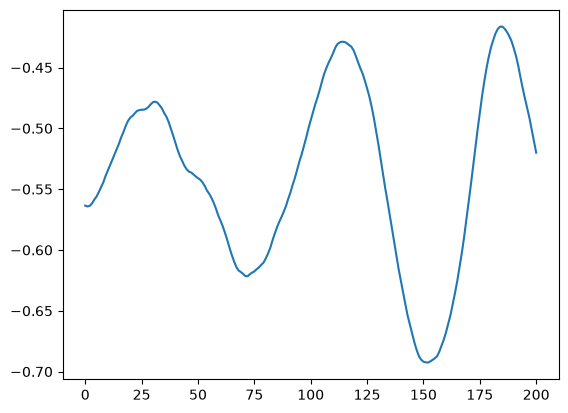

In [6]:
#Fit observation priors:
kdes = []
p0_grid = np.zeros((n+1,obs_d))
P0_grid = np.zeros((n+1,obs_d))

initial_p = np.zeros_like(initial_states)
initial_P =  np.zeros_like(initial_states)

x_grid = np.linspace(-0.03, -0.03, num =200)

for i in range(obs_d):

    # Fit prior distributions and transform data for rbp
    kde = gaussian_kde(observations.T[i])

    kdes.append(kde)
    p0_grid[:,i] = kde(observations.T[i])
    P0_grid[:,i] = np.mean(ndtr((observations.T[i] - kde.dataset.T) / np.sqrt(kde.covariance[0, 0])), axis=0)

    initial_p[:,i] = kde(initial_states.T[i])
    initial_P[:,i] = np.mean(ndtr((initial_states.T[i]-kde.dataset.T) / np.sqrt(kde.covariance[0,0])), axis = 0)
    

plt.plot(observations.T[0])


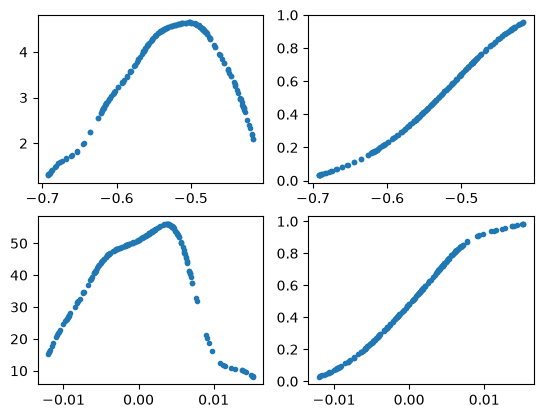

In [7]:
ptest = kdes[0](x_grid)
fig, ax = plt.subplots(2,2)
idx = 0
ax[0,0].plot(observations.T[idx], p0_grid.T[idx], '.')
ax[0,1].plot(observations.T[idx], P0_grid.T[idx], '.')
idx = 1
ax[1,0].plot(observations.T[idx], p0_grid.T[idx], '.')
ax[1,1].plot(observations.T[idx], P0_grid.T[idx], '.')

In [8]:
#Fit action beta prior:
# a, b, loc, scale = beta.fit(actions, floc = -1, fscale = 2)
# p0_grid[:, obs_d] = beta.pdf(actions, a, b, loc, scale).flatten()
# P0_grid[:, obs_d] = beta.cdf(actions, a, b, loc, scale).flatten()
# x_grid = np.linspace(-1, 1, num =200)
# plt.plot(x_grid, beta.pdf(x_grid, a, b, loc, scale))

class action_prior:
    def __init__(self, actions, action_set):
        if not isinstance(action_set, np.ndarray):
            raise ValueError("action_set should be a numpy array")

        self.action_set = action_set
        self.pmf_arr = np.zeros_like(action_set, dtype=float)
        self.cdf_arr = np.array([0.0])

        for i, val in enumerate(action_set):
            self.pmf_arr[i] = np.sum(actions == val) / len(actions)
            self.cdf_arr = np.append(self.cdf_arr, self.cdf_arr[i] + self.pmf_arr[i])

    def cdf(self, idx = 0, action = None, left_limit = False):
        if action is not None:
            raw_action = np.asarray(action)
            if raw_action.ndim == 0:
                raw_action = raw_action.item()
                if raw_action not in self.action_set:
                    raise ValueError(f"action={raw_action} is not in the discrete action set {self.action_set}.")
                idx = np.searchsorted(self.action_set, raw_action, side="left") + 1
            else:
                if not np.all(np.isin(raw_action, self.action_set)):
                    raise ValueError(f"All actions must be in {self.action_set}.")
                idx = np.searchsorted(self.action_set, raw_action, side="left") + 1

        if left_limit:
            left_idx = np.clip(idx - 1, 0, len(self.cdf_arr) - 1)
            return np.asarray(self.cdf_arr[left_idx])

        return np.asarray(self.cdf_arr[np.clip(idx, 0, len(self.cdf_arr) - 1)])

    def pmf(self, idx = 0, action = None):
        if action is not None:
            idx = np.where(self.action_set == action)[0]
        return self.pmf_arr[idx]

    def inv_cdf(self, cds):
        return 0


act_set = np.array([0,1,2])
acting_prior = action_prior(actions, act_set)

ac = np.expand_dims(acting_prior.cdf(action = actions.T), axis = 1)
ac_left = np.expand_dims(acting_prior.cdf(action = actions.T, left_limit=True), axis = 1)

initial_ac = np.expand_dims(acting_prior.cdf(action = initial_actions), axis = 1)
initial_ac_left = np.expand_dims(acting_prior.cdf(action = initial_actions, left_limit=True), axis = 1)
initial_ac.shape

(7, 1)

Now we apply the RBP process to all marginals: Should we scale the observation and action space to give us better fits? Can we do that? The reason it takes so long is optimising for a rho that is so close to one. 



In [9]:
rhos, Us = rbp.fit_R_BP_marginals(p0_grid,P0_grid)
print(rhos, Us.shape)
if np.any(rhos>0.99):
    print("Check the marginals: at least one rho is >0.99.")


[0.99845552 0.999     ] (201, 2)
Check the marginals: at least one rho is >0.99.


In [10]:
px, Px = rbp.R_BP_density_U(rhos, p0_grid, P0_grid, Us)
ipx, iPx = rbp.R_BP_density_U(rhos, initial_p, initial_P, Us)

print(initial_ac.shape)
print(iPx.shape)
# Px = np.hstack((Px, ac))
# iPx = np.hstack((iPx, initial_ac))
iPx.shape

(7, 1)
(7, 2)


(7, 2)

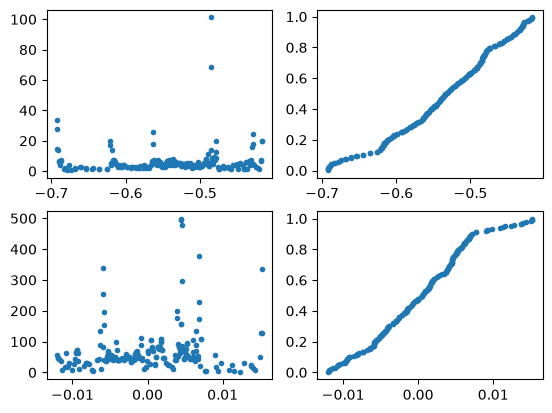

In [11]:
fig, ax = plt.subplots(2,2)
idx = 0
ax[0,0].plot(observations.T[idx], px.T[idx], '.')
ax[0,1].plot(observations.T[idx], Px.T[idx], '.')
idx = 1
ax[1,0].plot(observations.T[idx], px.T[idx], '.')
ax[1,1].plot(observations.T[idx], Px.T[idx], '.')

In [12]:
from torch.utils.data import Dataset
#reference this
class SlidingWindowDataset(Dataset):
    def __init__(self, data, window_size=10, steps_ahead=1):
        self.data = data
        self.steps_ahead = steps_ahead
        self.window_size = window_size
    def __len__(self):
        return len(self.data) - self.window_size - self.steps_ahead + 1
    def __getitem__(self, idx):
        if idx < 0: idx = len(self) + idx
        history = self.data[idx : idx + self.window_size]
        target = self.data[idx + self.window_size + self.steps_ahead - 1]
        return history, target

We should do the transformations as per usual, and then stack them, as of course each respective variable comes from the same distribution, we are just adding a time window.

We have now done the transformations, so we now create our dataset using the time window mechanics.

In [13]:
time_series = torch.from_numpy(Px)
ts = SlidingWindowDataset(time_series, window_size=3)
d_ts = SlidingWindowDataset(torch.from_numpy(ac), window_size=3)
left_ts = SlidingWindowDataset(torch.from_numpy(ac_left), window_size=3)

its = torch.from_numpy(iPx)
its = SlidingWindowDataset(its, window_size = 3)
d_its = SlidingWindowDataset(torch.from_numpy(initial_ac), window_size=3)
left_its = SlidingWindowDataset(torch.from_numpy(initial_ac_left), window_size=3)

#Get discrete and left limits of discrete to add to the end of the data to comply with pyvinecopulib.
d_data = torch.stack([history.flatten() for history, _ in d_ts]).squeeze(1)
left_data = torch.stack([history.flatten() for history, _ in left_ts]).squeeze(1)

d_idata = torch.stack([history.flatten() for history, _ in d_its]).squeeze(1)
left_idata = torch.stack([history.flatten() for history, _ in left_its]).squeeze(1)

data = torch.stack([torch.cat((target[0:obs_d], history.flatten())) for history, target in ts]).squeeze(1)
idata = torch.stack([torch.cat((target[0:obs_d], history.flatten())) for history, target in its]).squeeze(1)

data = torch.hstack((data, left_data, d_data)).numpy()
idata = torch.hstack((idata, left_idata, d_idata)).numpy()
data.shape

(198, 14)

We now need to take the transformed and constructed dataset, and fit a conditional vine copula on it. 

In [14]:
controls = pv.FitControlsVinecop() #family_set=[pv.gaussian]
controls.conditioning_set = [3,4,5,6,7,8,9,10,11]
cop = pv.Vinecop.from_data(data, var_types = ["c"]*8+["d"]*3, controls=controls)


In [15]:
print(idata[0,2:])
print(cop)
print(idata.shape)


[0.34449266 0.47320536 0.33502934 0.45279817 0.34231968 0.50676688
 0.4079602  0.4079602  0.4079602  0.74626866 0.74626866 0.74626866]
<pyvinecopulib.core.Vinecop> Vinecop model with 11 variables
tree edge conditioned variables      conditioning variables var_types       family rotation parameters  df   tau 
   1    1                  1, 7                                  c, c      Student        0 0.99, 6.83 2.0  0.93 
   1    2                  2, 8                                  c, c        Frank        0      33.19 1.0  0.89 
   1    3                  3, 5                                  c, c      Student        0 0.99, 6.61 2.0  0.93 
   1    4                  5, 7                                  c, c      Student        0 0.99, 6.72 2.0  0.93 
   1    5                  7, 4                                  c, c     Gaussian        0       0.23 1.0  0.14 
   1    6                  4, 6                                  c, c        Frank        0      33.07 1.0  0.89 
   1  

Now we want to sample from the copula to do thompson sampling? 

We want to use this model to improve our policy, then apply our policy.

We do not learn the reward function here, but rather simplify by having that be the deterministic, true reward function.



In [16]:
def calc_reward(action):
    return -1

def check_termination(state, episode):
    if episode > 200 or state[0]>=0.5:
        return True
    return False
    


So we have a model for the environment. Now what we want to do is sample from that model and update our policy with respect to the chains that we get from this policy.

Sampling from that model can take two forms:

Metropolis hastings with a proposal on the observation space (requires conditional pdf)

Root finding from a sample from the model. i.e. perform the inverse operation to get back to the observation space when you 

The actions currently do not correspond exactly when sampled from the joint distribution. This might not matter so much if we instead get a blank start, and then model the next state given those actions.

In [17]:
class model:
    def __init__(self, vine:pv.Vinecop):
        self.vine = vine
        self.ing_set = vine.conditioning_set

    def sample(self, state_and_action):
        return self.vine.simulate_conditional(state_and_action)




In [40]:
class thompson_sampler:
    def __init__(self, actions, rewards, action_set):
        self.distributions = []
        self.distribution_parameters
        for act in action_set:
            self.distributions.append(beta)

def get_order_mask(order:list, n_discrete:int)->np.ndarray:
    largest_idx = max(order)
    mask = order
    for i in range((largest_idx+1),(largest_idx+1+n_discrete)):
        mask.append(i)
    return np.array(mask)-1

def get_inv_order_mask(mask:np.ndarray, n_discrete:int)->np.ndarray:
    inv_mask = np.zeros_like(mask)
    for i, idx in enumerate(mask):
        inv_mask[idx] = i
    return inv_mask

def plan_action(dynamics_model: pv.Vinecop, state, action_set, action_transform: action_prior, horizon, n_simulations = 50, gen = np.random.default_rng()):
    best_action = None
    best_return = -float('inf')
    order_mask = get_order_mask(dynamics_model.order, 3)
    print(order_mask)
    inv = get_inv_order_mask(order_mask, 3)
    print(inv)
    print("---------------")
    print(state)
    t = state[order_mask]
    print(t[inv])
    print("---------------")
    
    for _ in range(n_simulations):
        simulated_state = state.copy()
        total_return = 0
        for _ in range(horizon):
            action = gen.choice(action_set)

            #transform action here
            u_action = action_transform.cdf(action = action)
            u_action_left_lim = action_transform.cdf(action = action, left_limit = True)

            #THis is wrong
            state_and_action = np.insert(simulated_state[:-4], 2, [ u_action_left_lim, u_action]) # Insert the action F and F^- in 
            print(state_and_action)

            simulated_state = simulated_state[order_mask]
            print(simulated_state)
            print(dynamics_model.pdf(np.array([simulated_state])))
            next_state_pred = dynamics_model.simulate_conditional(np.array([something]))

            reward = -1.0

            total_return += reward
            simulated_state = next_state_pred

        if total_return > best_return:
            best_return = total_return
            best_action = action
    return best_action

#Put State into the correct order based on the vine order so we can sample from the vine...



plan_action(cop, idata[0], act_set, acting_prior, horizon = 10)

# array([0.29046836, 0.48882365, 0.29229908, 0.40417069, 0.34328358,
#        0.        , 0.28314487, 0.35825489, 0.67661692, 0.34328358,
#        0.26895198, 0.37483646, 1.        , 0.67661692])

[ 0  1  2  4  6  3  5  9  7  8 10 11 12 13]
[ 0  1  2  5  3  6  4  8  9  7 10 11 12 13]
---------------
[0.35404203 0.59441266 0.34449266 0.47320536 0.33502934 0.45279817
 0.34231968 0.50676688 0.4079602  0.4079602  0.4079602  0.74626866
 0.74626866 0.74626866]
[0.35404203 0.59441266 0.34449266 0.47320536 0.33502934 0.45279817
 0.34231968 0.50676688 0.4079602  0.4079602  0.4079602  0.74626866
 0.74626866 0.74626866]
---------------
[0.35404203 0.59441266 0.         0.4079602  0.34449266 0.47320536
 0.33502934 0.45279817 0.34231968 0.50676688 0.4079602  0.4079602 ]
[0.35404203 0.59441266 0.34449266 0.33502934 0.34231968 0.47320536
 0.45279817 0.4079602  0.50676688 0.4079602  0.4079602  0.74626866
 0.74626866 0.74626866]
[2.61502167e-26]


NameError: name 'something' is not defined